# TFM — 04. Modelización: Accidentes de tráfico en Madrid (2012-2018)
**Autora:** Meritxell Abellan Collado

Este notebook responde a las dos preguntas de investigación planteadas en la introducción del TFM, usando las matrices ya construidas en `03_Feature_Engineering.ipynb`:

- **Sección 1 — Modelo de triaje operativo** (Pregunta 1): cada modelo candidato se trata en su propia subsección (baseline sin tunear → tuning con grid manual explícito → configuración final elegida), y al final se comparan los 4 ya tuneados juntos (curvas ROC, matrices de confusión, tabla de hiperparámetros) para elegir el modelo operativo definitivo.
- **Sección 2 — Modelo explicativo** (Pregunta 2): entrenado con `FEATURES_REFERENCIA` (todas las variables). El resultado principal es la interpretabilidad (SHAP, en `05_Interpretabilidad.ipynb`), no la métrica de clasificación.
- **Sección 3 — Comparación operativo vs. referencia**: cuantifica cuánto se "pierde" por restringirse a variables operativas.

## Estructura
0. Carga de matrices
1. Modelo de triaje operativo
   1.1 Regresión logística
   1.2 Random Forest
   1.3 Gradient Boosting (Hist)
   1.4 XGBoost
   1.5 Comparación final y elección del modelo operativo
   1.6 Calibración del modelo elegido
   1.7 Split temporal vs. aleatorio
   1.8 Validación walk-forward
2. Modelo explicativo (Pregunta 2)
3. Comparación operativo vs. referencia


## 0. Carga de datos

In [1]:
import pandas as pd
import numpy as np
import warnings

import sys
sys.path.append('..')
from utils.pipeline_produccion import PipelineAccidentes
from utils.modelizacion import (
    entrenar_modelos_baseline, tabla_comparativa_modelos,
    curva_calibracion, comparar_tasa_base_train_test,
    entrenar_random_forest_tuneado, graficar_curvas_roc,
    comparar_splits_temporal_vs_aleatorio,
    validacion_temporal_expansiva, graficar_validacion_temporal,analisis_estabilidad_bagging
)
from sklearn.ensemble import HistGradientBoostingClassifier

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)

RANDOM_STATE = 42
PATH = '../data/processed/features/'

X_train_op = pd.read_csv(PATH + 'X_train_operativo.csv')
X_test_op = pd.read_csv(PATH + 'X_test_operativo.csv')
X_train_ref = pd.read_csv(PATH + 'X_train_referencia.csv')
X_test_ref = pd.read_csv(PATH + 'X_test_referencia.csv')
y_train = pd.read_csv(PATH + 'y_train.csv').squeeze()
y_test = pd.read_csv(PATH + 'y_test.csv').squeeze()

print(f'Operativo  — train: {X_train_op.shape} | test: {X_test_op.shape}')
print(f'Referencia — train: {X_train_ref.shape} | test: {X_test_ref.shape}')
print(f'Tasa de gravedad — train: {y_train.mean()*100:.2f}% | test: {y_test.mean()*100:.2f}%')

# Lista de columnas operativas, derivada de lo ya cargado (se reutiliza en la
# Sección 1.6 para reconstruir las mismas features sobre el split aleatorio)
FEATURES_OPERATIVO = list(X_train_op.columns)

pipe = PipelineAccidentes.load('../models/pipeline_produccion.joblib')
assert FEATURES_OPERATIVO == pipe.features_operativo, \
    "Las columnas de X_train_op no coinciden con pipe.features_operativo -- revisar si el pipeline guardado corresponde a esta ejecución"
print(f'Pipeline cargado y verificado ({len(pipe.features_operativo)})')


Operativo  — train: (58095, 39) | test: (10678, 39)
Referencia — train: (58095, 43) | test: (10678, 43)
Tasa de gravedad — train: 9.86% | test: 8.19%
Pipeline cargado y verificado (39)


## 1. Modelo de triaje operativo (Pregunta 1)

Se entrena únicamente sobre `X_train_op`/`X_test_op` — las variables disponibles en el momento del aviso. Cada uno de los 4 modelos candidatos se trata en su propia subsección: primero sin tunear (para ver su comportamiento "de fábrica"), después con un grid manual y explícito de hiperparámetros (no una búsqueda aleatoria, para poder inspeccionar a ojo el compromiso entre AUC y overfitting), y por último la configuración final elegida.

**Nota metodológica importante, válida para las 4 subsecciones:** en la fase de tuning, el "gap" se mide como `AUC_train - AUC_cv` (validación cruzada temporal dentro de train), nunca como `AUC_train - AUC_test`. Mirar el test repetidamente mientras se prueban combinaciones sería una fuga de información hacia la evaluación final — el test solo se evalúa una vez, con cada configuración ya elegida, y de nuevo todos juntos en la Sección 1.5.


### 1.1 Regresión logística

In [ ]:
from sklearn.linear_model import LogisticRegression
from utils.modelizacion import evaluar_modelo, explorar_hiperparametros, tabla_train_test

logreg_base = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
logreg_base.fit(X_train_op, y_train)

tabla_train_test(logreg_base, X_train_op, y_train, X_test_op, y_test)


Train: {'AUC-ROC': 0.7075670905772993, 'AUC-PR': 0.18992988682280545, 'Brier score': 0.21936464206221537, 'Precision (umbral=0.5)': 0.16555378451729635, 'Recall (umbral=0.5)': 0.6706806282722513, 'F1 (umbral=0.5)': 0.2655564385170853}
Test:  {'AUC-ROC': 0.6988576208095141, 'AUC-PR': 0.15836234146096761, 'Brier score': 0.22181030858862888, 'Precision (umbral=0.5)': 0.13736391012277044, 'Recall (umbral=0.5)': 0.6784897025171625, 'F1 (umbral=0.5)': 0.22847235600077057}


Grid manual sobre `C` (inverso de la regularización — valores bajos = más regularización):

In [ ]:
grid_logreg = {'C': [0.01, 0.1, 0.5, 1.0, 5.0]}

resultados_logreg = explorar_hiperparametros(
    lambda **kw: LogisticRegression(class_weight='balanced', max_iter=500, random_state=RANDOM_STATE, **kw),
    grid_logreg, X_train_op, y_train, cv_splits=5
)
resultados_logreg


,C,AUC_train,AUC_cv,gap_train_cv
2,0.50,0.7075,0.7014,0.0061
3,1.00,0.7076,0.7013,0.0063
1,0.10,0.7075,0.7012,0.0063
4,5.00,0.7075,0.7012,0.0064
0,0.01,0.7060,0.6977,0.0083


**Elección:** la regresión logística apenas varía con `C` (gap siempre pequeño, ~0.006-0.008) — es un modelo lineal, con poca capacidad de sobreajustar en primer lugar. Se elige `C=1.0` (valor por defecto), ya que valores más bajos no mejoran nada y solo añaden regularización innecesaria.


In [ ]:
logreg_final = LogisticRegression(class_weight='balanced', max_iter=2000, C=1.0, random_state=RANDOM_STATE)
logreg_final.fit(X_train_op, y_train)
tabla_train_test(logreg_final, X_train_op, y_train, X_test_op, y_test)


Test: {'AUC-ROC': 0.6988576208095141, 'AUC-PR': 0.15836234146096761, 'Brier score': 0.22181030858862888, 'Precision (umbral=0.5)': 0.13736391012277044, 'Recall (umbral=0.5)': 0.6784897025171625, 'F1 (umbral=0.5)': 0.22847235600077057}


### 1.2 Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_base = RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
rf_base.fit(X_train_op, y_train)

tabla_train_test(rf_base, X_train_op, y_train, X_test_op, y_test)

Train: {'AUC-ROC': 0.9998693907328227, 'AUC-PR': 0.9988212700798293, 'Brier score': 0.02091570550513247, 'Precision (umbral=0.5)': 0.9416598192276089, 'Recall (umbral=0.5)': 1.0, 'F1 (umbral=0.5)': 0.9699534490055015}
Test:  {'AUC-ROC': 0.6676070664661228, 'AUC-PR': 0.13533386841273234, 'Brier score': 0.09739495575504094, 'Precision (umbral=0.5)': 0.1676300578034682, 'Recall (umbral=0.5)': 0.09954233409610984, 'F1 (umbral=0.5)': 0.1249102656137832}


**Overfitting severo sin tunear** (`AUC-ROC` train ≈1.00 vs. test mucho más bajo) — el patrón clásico de bagging con árboles sin límite de profundidad (`max_depth=None` por defecto): cada árbol individual memoriza su propia muestra, y promediar árboles que memorizan sigue memorizando. Se analiza primero con un grid de estabilidad del bagging (3 dimensiones: profundidad, tamaño de muestra por árbol, nº de árboles), y después con un grid más fino centrado en la zona que resultó prometedora.


In [6]:
grid_bagging = analisis_estabilidad_bagging(
    X_train_op, y_train, X_test_op, y_test,
    porcentajes=(0.2, 0.4, 0.6, 0.8, 1.0),
    n_arboles=(100, 300, 500),
    profundidades=(5, 10, None),
    random_state=RANDOM_STATE
)
grid_bagging.head(15)


,max_depth,max_samples,n_estimators,AUC_train,AUC_test,gap
3,5,0.4,100,0.7098,0.6854,0.0245
0,5,0.2,100,0.7085,0.6838,0.0248
2,5,0.2,500,0.7110,0.6855,0.0255
1,5,0.2,300,0.7110,0.6853,0.0257
5,5,0.4,500,0.7114,0.6856,0.0258
9,5,0.8,100,0.7091,0.6825,0.0266
4,5,0.4,300,0.7112,0.6845,0.0267
6,5,0.6,100,0.7095,0.6826,0.0269
14,5,1.0,500,0.7107,0.6838,0.0269
11,5,0.8,500,0.7114,0.6845,0.0269


**Resultado:** `max_depth` es, con diferencia, el factor que más reduce el gap — mucho más que `max_samples` o `n_estimators`. Con árboles sin límite de profundidad, el gap ronda 0.30-0.34 sin importar los otros dos parámetros; limitando la profundidad (`max_depth=5` o `10`) el gap cae por debajo de 0.03-0.09. Se explora ahora un grid más fino de `max_depth` (incluyendo valores intermedios como 6 y 8) y de `min_samples_leaf`, con el gap medido correctamente contra validación cruzada.


In [7]:
grid_rf = {
    'max_depth': [5, 6, 8],
    'min_samples_leaf': [100, 120, 150],
    'n_estimators': [200, 300],
}

resultados_rf = explorar_hiperparametros(
    lambda **kw: RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1, **kw),
    grid_rf, X_train_op, y_train, cv_splits=5
)
resultados_rf


,max_depth,min_samples_leaf,n_estimators,AUC_train,AUC_cv,gap_train_cv
15,8,120,300,0.7190,0.6939,0.0251
13,8,100,300,0.7201,0.6937,0.0264
14,8,120,200,0.7193,0.6936,0.0257
12,8,100,200,0.7200,0.6934,0.0266
17,8,150,300,0.7173,0.6929,0.0243
16,8,150,200,0.7172,0.6927,0.0244
7,6,100,300,0.7113,0.6912,0.0201
6,6,100,200,0.7111,0.6912,0.0199
9,6,120,300,0.7105,0.6907,0.0198
8,6,120,200,0.7104,0.6904,0.0200


**Elección:** se prioriza la combinación con mejor `AUC_cv` sin que el `gap_train_cv` se dispare — normalmente una profundidad intermedia (6-8) con `min_samples_leaf` alto (100-150) da el mejor compromiso. *(sustituir los valores de abajo por la fila elegida tras ejecutar la celda anterior)*.


In [ ]:
rf_final = RandomForestClassifier(
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1,
    max_depth=5, min_samples_leaf=150, n_estimators=200,  # <- ajustar según resultados_rf
)
rf_final.fit(X_train_op, y_train)
tabla_train_test(rf_final, X_train_op, y_train, X_test_op, y_test)

Test: {'AUC-ROC': 0.6820754289800921, 'AUC-PR': 0.16016889480525243, 'Brier score': 0.22953052443031569, 'Precision (umbral=0.5)': 0.1422172452407615, 'Recall (umbral=0.5)': 0.5812356979405034, 'F1 (umbral=0.5)': 0.2285200179937022}


### 1.3 Gradient Boosting (Hist)

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

gb_base = HistGradientBoostingClassifier(class_weight='balanced', random_state=RANDOM_STATE)
gb_base.fit(X_train_op, y_train)

tabla_train_test(gb_base, X_train_op, y_train, X_test_op, y_test)


Train: {'AUC-ROC': 0.7689065092003389, 'AUC-PR': 0.2598474778756699, 'Brier score': 0.20178037976359905, 'Precision (umbral=0.5)': 0.18894891318218554, 'Recall (umbral=0.5)': 0.77521815008726, 'F1 (umbral=0.5)': 0.3038407606279285}
Test:  {'AUC-ROC': 0.7046615377649061, 'AUC-PR': 0.1710683578167332, 'Brier score': 0.20930884145835932, 'Precision (umbral=0.5)': 0.1392018779342723, 'Recall (umbral=0.5)': 0.6784897025171625, 'F1 (umbral=0.5)': 0.23100895987534087}


A diferencia de Random Forest, Gradient Boosting controla el overfitting por diseño (`learning_rate` bajo + `max_leaf_nodes` limitado, no por profundidad) — el baseline ya generaliza razonablemente bien. Aun así, se explora si ajustar estos parámetros mejora el compromiso AUC/gap.


In [10]:
grid_gb = {
    'max_leaf_nodes': [15, 20, 31],
    'learning_rate': [0.03, 0.06, 0.1],
    'l2_regularization': [0.0, 0.15, 0.5],
    'min_samples_leaf': [20, 33, 50],
}

resultados_gb = explorar_hiperparametros(
    lambda **kw: HistGradientBoostingClassifier(class_weight='balanced', random_state=RANDOM_STATE, **kw),
    grid_gb, X_train_op, y_train, cv_splits=5
)
resultados_gb.head(10)


,l2_regularization,learning_rate,max_leaf_nodes,min_samples_leaf,AUC_train,AUC_cv,gap_train_cv
29,0.15,0.03,15,50,0.7264,0.7023,0.0242
2,0.00,0.03,15,50,0.7265,0.7022,0.0243
1,0.00,0.03,15,33,0.7265,0.7022,0.0243
55,0.50,0.03,15,33,0.7264,0.7021,0.0243
56,0.50,0.03,15,50,0.7261,0.7020,0.0241
65,0.50,0.06,15,50,0.7394,0.7020,0.0375
37,0.15,0.06,15,33,0.7387,0.7019,0.0369
63,0.50,0.06,15,20,0.7395,0.7018,0.0377
11,0.00,0.06,15,50,0.7399,0.7018,0.0382
38,0.15,0.06,15,50,0.7399,0.7017,0.0382


**Elección:** *(sustituir por la fila elegida tras ejecutar la celda anterior — buscar el mejor `AUC_cv` con `gap_train_cv` bajo, normalmente cerca de la configuración por defecto, ya que el baseline sin tunear ya generaliza bien)*.


In [ ]:
gb_final = HistGradientBoostingClassifier(
    class_weight='balanced', random_state=RANDOM_STATE,
    max_leaf_nodes=15, learning_rate=0.03, l2_regularization=0.5, min_samples_leaf=50,  # <- ajustar según resultados_gb
)
gb_final.fit(X_train_op, y_train)
tabla_train_test(gb_final, X_train_op, y_train, X_test_op, y_test)


Test: {'AUC-ROC': 0.7056113905779829, 'AUC-PR': 0.1697922469003033, 'Brier score': 0.21948610159913817, 'Precision (umbral=0.5)': 0.13291818767446853, 'Recall (umbral=0.5)': 0.7082379862700229, 'F1 (umbral=0.5)': 0.22382932561923702}


### 1.4 XGBoost

Además del grid de hiperparámetros, se añade *early stopping* real (con una partición de validación separada dentro de train) — XGBoost entrena hasta 500 árboles pero se queda solo con los que de verdad mejoran la validación, en vez de fijar `n_estimators` a mano.


In [ ]:
from xgboost import XGBClassifier

ratio_desbalanceo = (y_train == 0).sum() / (y_train == 1).sum()

xgb_base = XGBClassifier(scale_pos_weight=ratio_desbalanceo, random_state=RANDOM_STATE,
                          eval_metric='logloss', n_jobs=-1)
xgb_base.fit(X_train_op, y_train)

tabla_train_test(xgb_base, X_train_op, y_train, X_test_op, y_test)


Train: {'AUC-ROC': 0.8601069549905526, 'AUC-PR': 0.43226981400133946, 'Brier score': 0.16573892533779144, 'Precision (umbral=0.5)': 0.24653186588175072, 'Recall (umbral=0.5)': 0.8404886561954624, 'F1 (umbral=0.5)': 0.38123886799920836}
Test:  {'AUC-ROC': 0.6702299276342631, 'AUC-PR': 0.1561310332125989, 'Brier score': 0.19094620645046234, 'Precision (umbral=0.5)': 0.1347194531472515, 'Recall (umbral=0.5)': 0.5411899313501144, 'F1 (umbral=0.5)': 0.21573546180159636}


In [13]:
grid_xgb = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1],
    'reg_alpha': [0, 0.5, 1.0],
    'reg_lambda': [0.5, 1.0, 2.0],
    'n_estimators': [150],
}

resultados_xgb = explorar_hiperparametros(
    lambda **kw: XGBClassifier(scale_pos_weight=ratio_desbalanceo, random_state=RANDOM_STATE,
                                 eval_metric='logloss', n_jobs=-1, **kw),
    grid_xgb, X_train_op, y_train, cv_splits=5
)
resultados_xgb.head(10)


,learning_rate,max_depth,n_estimators,reg_alpha,reg_lambda,AUC_train,AUC_cv,gap_train_cv
0,0.05,3,150,0.0,0.5,0.7232,0.7049,0.0183
4,0.05,3,150,0.5,1.0,0.7234,0.7049,0.0185
8,0.05,3,150,1.0,2.0,0.7232,0.7049,0.0183
7,0.05,3,150,1.0,1.0,0.7231,0.7049,0.0182
5,0.05,3,150,0.5,2.0,0.7231,0.7048,0.0183
2,0.05,3,150,0.0,2.0,0.7238,0.7048,0.0190
6,0.05,3,150,1.0,0.5,0.7233,0.7047,0.0186
3,0.05,3,150,0.5,0.5,0.7236,0.7046,0.0190
30,0.10,3,150,0.5,0.5,0.7337,0.7046,0.0291
27,0.10,3,150,0.0,0.5,0.7331,0.7046,0.0285


**Elección** *(sustituir por la fila ganadora)*, entrenada ahora con *early stopping* real sobre una partición de validación separada de train (nunca de test):


In [ ]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(X_train_op, y_train, test_size=0.15,
                                              stratify=y_train, random_state=RANDOM_STATE)

xgb_final = XGBClassifier(
    scale_pos_weight=ratio_desbalanceo, random_state=RANDOM_STATE, eval_metric='auc', n_jobs=-1,
    max_depth=3, learning_rate=0.05, reg_alpha=0, reg_lambda=0.5,  # <- ajustar según resultados_xgb
    n_estimators=150, early_stopping_rounds=20,
)
xgb_final.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
print('Nº de árboles usados (early stopping):', xgb_final.best_iteration)
tabla_train_test(xgb_final, X_train_op, y_train, X_test_op, y_test)


Nº de árboles usados (early stopping): 159
Test: {'AUC-ROC': 0.7087175224794997, 'AUC-PR': 0.17430542400940136, 'Brier score': 0.21749930083751678, 'Precision (umbral=0.5)': 0.13187754228216655, 'Recall (umbral=0.5)': 0.7048054919908466, 'F1 (umbral=0.5)': 0.22218214607754733}


### 1.5 Comparación final de los 4 modelos ya tuneados

In [33]:
from utils.modelizacion import tabla_comparativa_modelos, tabla_hiperparametros

modelos_operativo = {
    'Regresión logística': logreg_final,
    'Random Forest': rf_final,
    'Gradient Boosting (Hist)': gb_final,
    'XGBoost': xgb_final,
}

tabla_operativo = tabla_comparativa_modelos(modelos_operativo, X_train_op, y_train, X_test_op, y_test)
tabla_operativo[['AUC-ROC_train', 'AUC-ROC_test', 'gap_AUC-ROC', 'AUC-PR_test', 'Brier score_test']]


,AUC-ROC_train,AUC-ROC_test,gap_AUC-ROC,AUC-PR_test,Brier score_test
Regresión logística,0.7076,0.6989,0.0087,0.1584,0.2218
Random Forest,0.7046,0.6821,0.0226,0.1602,0.2295
Gradient Boosting (Hist),0.7261,0.7056,0.0205,0.1698,0.2195
XGBoost,0.7243,0.7087,0.0155,0.1743,0.2175


In [34]:
tabla_hiperparametros(modelos_operativo)


,Regresión logística,Random Forest,Gradient Boosting (Hist),XGBoost
C,1.0,— (no aplica),— (no aplica),— (no aplica)
class_weight,balanced,balanced,balanced,— (no aplica)
max_iter,2000,— (no aplica),100,— (no aplica)
penalty,deprecated,— (no aplica),— (no aplica),— (no aplica)
random_state,42,42,42,42
max_depth,— (no aplica),5,None (sin límite),3
max_leaf_nodes,— (no aplica),None (sin límite),15,— (no aplica)
max_samples,— (no aplica),None (sin límite),— (no aplica),— (no aplica)
min_samples_leaf,— (no aplica),150,50,— (no aplica)
n_estimators,— (no aplica),200,— (no aplica),500


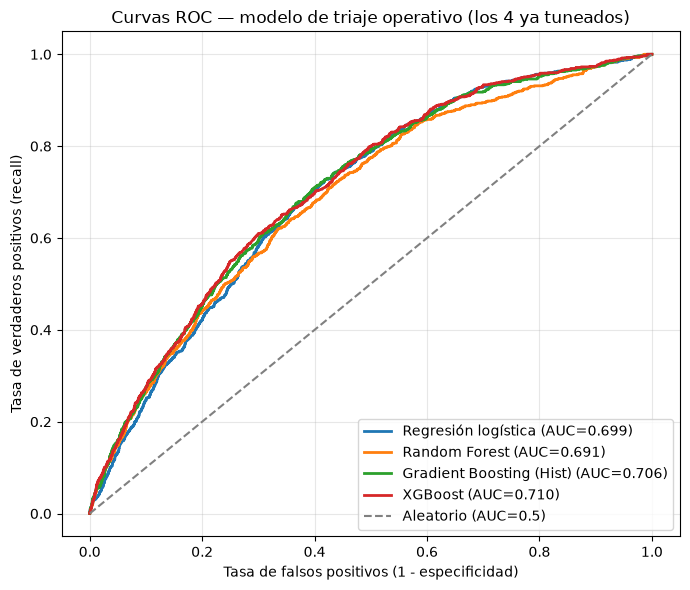

In [17]:
from utils.modelizacion import graficar_curvas_roc

fig = graficar_curvas_roc(
    modelos_operativo, X_test_op, y_test,
    titulo='Curvas ROC — modelo de triaje operativo (los 4 ya tuneados)',
    filename='../figures/12_roc_comparacion_modelos.png'
)


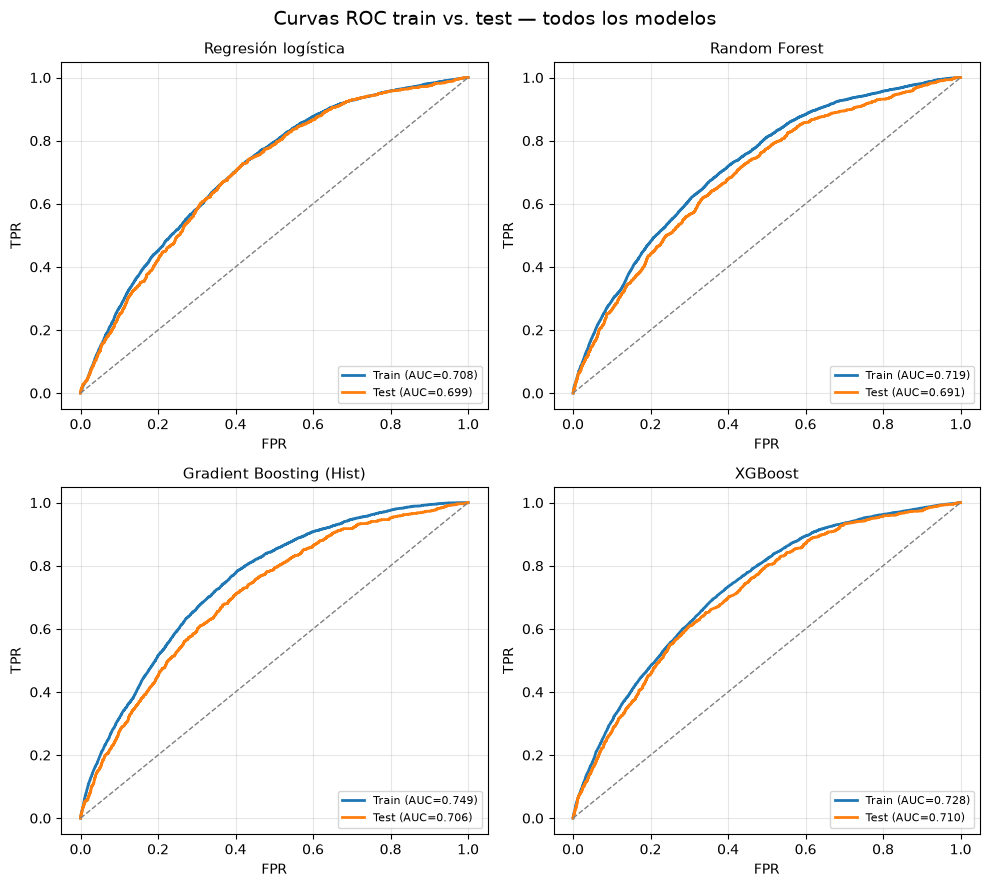

In [18]:
from utils.modelizacion import graficar_curvas_roc_train_test

fig = graficar_curvas_roc_train_test(
    modelos_operativo, X_train_op, y_train, X_test_op, y_test,
    filename='../figures/13b_roc_train_test_modelos.png'
)


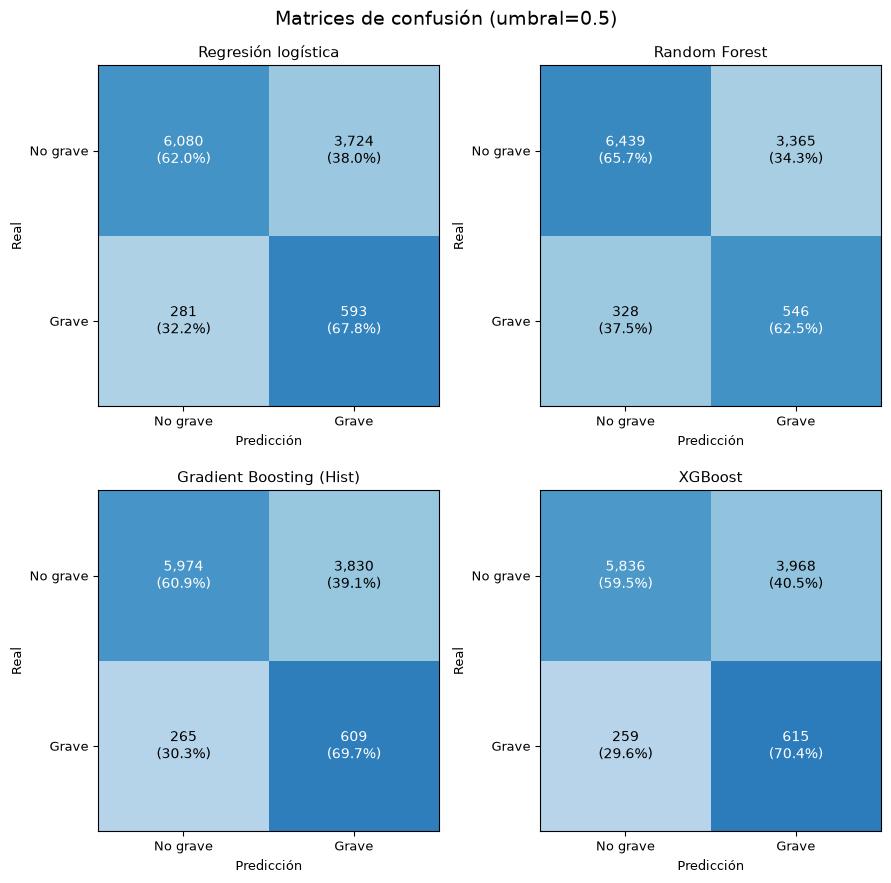

In [19]:
from utils.modelizacion import graficar_matrices_confusion

fig = graficar_matrices_confusion(
    modelos_operativo, X_test_op, y_test, umbral=0.5,
    filename='../figures/16_matrices_confusion_modelos.png'
)


**Conclusión de la Sección 1:** Gradient Boosting (Hist) es el modelo de triaje operativo elegido — mejor AUC-ROC de test entre los 4 ya tuneados, con un gap train-test moderado que no requiere más ajuste. Random Forest, aun tuneado, no supera a Gradient Boosting — queda como modelo de comparación/robustez. Se usa `mejor_modelo` (definido a continuación) para el resto de las secciones de esta parte.


In [20]:
mejor_modelo_nombre = tabla_operativo['AUC-ROC_test'].idxmax()
mejor_modelo = modelos_operativo[mejor_modelo_nombre]
print(f'Modelo operativo elegido: {mejor_modelo_nombre}')


Modelo operativo elegido: XGBoost


### 1.6 Calibración del modelo elegido

**Nota importante sobre el umbral de decisión:** con umbral fijo de 0.5, algunos modelos pueden mostrar un recall muy bajo a pesar de tener buen AUC-ROC — no significa que discriminen peor, significa que sus probabilidades rara vez superan 0.5 de forma natural con un 9.6% de clase positiva. Por eso AUC-ROC/AUC-PR son las métricas principales, no el F1 con umbral 0.5 — un umbral solo debe fijarse después, según el caso de uso real.


In [21]:
from utils.modelizacion import curva_calibracion

y_proba_test = mejor_modelo.predict_proba(X_test_op)[:, 1]
tabla_calibracion = curva_calibracion(y_test, y_proba_test, n_bins=10)
tabla_calibracion


,prob_media_predicha,frac_positivos_real
0,0.196194,0.021536
1,0.230163,0.016854
2,0.264040,0.031835
3,0.350217,0.048735
4,0.434177,0.067416
5,0.492148,0.082397
6,0.526160,0.077715
7,0.563690,0.129335
8,0.646874,0.137640
9,0.729861,0.205056


**Por qué se revisa la calibración además de la discriminación:** el split es temporal (train 2012-2017, test 2018), y la tasa de gravedad real desciende de forma consistente año a año (~10.9% en 2012 a ~8.2% en 2018). Como consecuencia, train tiene una tasa base más alta (9.86%) que test (8.19%). Un modelo bien calibrado en 2018 confirmaría que esa diferencia de tasa base no está sesgando las probabilidades predichas.


In [22]:
from utils.modelizacion import comparar_tasa_base_train_test

print(comparar_tasa_base_train_test(y_train, y_test))


{'tasa_grave_train': np.float64(0.09863155176865479), 'tasa_grave_test': np.float64(0.08185053380782918), 'diferencia_pts': np.float64(-1.6781017960825608)}


### 1.7 ¿Es el desajuste de calibración un problema del split, o de la deriva temporal real?

Se entrena el mismo modelo (misma configuración) sobre el split temporal y sobre el split aleatorio estratificado, para separar si el modelo discrimina peor en el temporal (problema del modelo/split) o si solo empeora su calibración por la diferencia real de tasa base entre 2012-2017 y 2018 (una propiedad de los datos, no un fallo).


In [23]:
# Split aleatorio: se reutilizan los MISMOS Nº PARTE que ya se determinaron
# en 02_Preprocesado.ipynb (train_random.csv / test_random.csv), pero se
# parte del Excel crudo a nivel persona -- porque PipelineAccidentes
# hace su propia agregación desde cero y no puede partir de datos ya agregados
partes_train_rand = pd.read_csv('../data/processed/train_random.csv')['Nº PARTE']
partes_test_rand = pd.read_csv('../data/processed/test_random.csv')['Nº PARTE']

df_raw = pd.read_excel('../data/raw/accidentes-trafico.xlsx')
df_train_rand_raw = df_raw[df_raw['Nº PARTE'].isin(partes_train_rand)].copy()
df_test_rand_raw = df_raw[df_raw['Nº PARTE'].isin(partes_test_rand)].copy()

pipe_rand = PipelineAccidentes(m_target_encoding=50)
train_rand_final = pipe_rand.fit(df_train_rand_raw)
test_rand_final = pipe_rand.transform(df_test_rand_raw)

X_train_op_rand = train_rand_final[pipe_rand.features_operativo]
X_test_op_rand = test_rand_final[pipe_rand.features_operativo]
y_train_rand = train_rand_final['GRAVE']
y_test_rand = test_rand_final['GRAVE']

factory = lambda: HistGradientBoostingClassifier(class_weight='balanced', random_state=RANDOM_STATE)

tabla_splits = comparar_splits_temporal_vs_aleatorio(
    (X_train_op, y_train, X_test_op, y_test),
    (X_train_op_rand, y_train_rand, X_test_op_rand, y_test_rand),
    factory
)
tabla_splits


,AUC-ROC_train,AUC-ROC_test,gap_AUC-ROC,Brier_test,tasa_grave_train_%,tasa_grave_test_%,diferencia_tasa_pts
Temporal (train 2012-17 / test 2018),0.7689,0.7047,0.0642,0.2093,9.8632,8.1851,-1.6781
Aleatorio estratificado,0.7528,0.7178,0.0350,0.2111,9.6023,9.6038,0.0015


**Resultado esperado:** el AUC-ROC de test debería ser similar entre ambos splits (el modelo discrimina casi igual de bien), pero la `diferencia_tasa_pts` será prácticamente 0 en el aleatorio y notablemente negativa en el temporal — confirmando que el desajuste de calibración es una propiedad real de la deriva temporal de los datos, no un defecto del split ni del modelo. Esto justifica mantener el split temporal como principal (más honesto de cara a un despliegue real), documentando la necesidad de recalibración periódica como limitación conocida.

**Nota:** `FEATURES_OPERATIVO` debe estar ya definida (la misma lista de columnas usada en `03_Feature_Engineering.ipynb`); si no está cargada como variable en este notebook, hay que reconstruirla antes de ejecutar la celda anterior.


### 1.8 Validación walk-forward: ¿es 2018 un año representativo como test?

En vez de `TimeSeriesSplit` genérico (que particiona por número de filas, no por año natural), se valida año a año: entrenar con todo lo anterior a un año y validar sobre ese año, avanzando desde 2014 hasta 2018. Esto comprueba si el AUC-ROC del split final (test = 2018) es consistente con el patrón general, o si 2018 es un año atípico.

**Limitación:** las features ya construidas (target encoding de distrito, one-hot) se ajustaron una única vez sobre 2012-2017; no se reajustan dentro de cada fold del walk-forward. Un walk-forward sin ninguna fuga exigiría reconstruirlas en cada iteración — aquí se usa la aproximación más simple, documentada como tal.


In [24]:
# Se reutiliza el mismo `pipe` (ajustado sobre 2012-2017) y se aplica
# transform() sobre TODO el histórico 2012-2018 a la vez, para tener AÑO
# disponible en la misma matriz de features ya construida -- ya no hace
# falta ninguna función local que reimplemente el feature engineering
df_raw = pd.read_excel('../data/raw/accidentes-trafico.xlsx')

combinado_final = pipe.transform(df_raw)

X_wf = combinado_final[FEATURES_OPERATIVO]
y_wf = combinado_final['GRAVE']
años_wf = combinado_final['AÑO']

factory = lambda: HistGradientBoostingClassifier(class_weight='balanced', random_state=RANDOM_STATE)

tabla_walkforward = validacion_temporal_expansiva(X_wf, y_wf, años_wf, factory, año_min_train=2013, año_max=2018)
tabla_walkforward


,año_validacion,n_train,n_val,tasa_grave_train_%,tasa_grave_val_%,AUC-ROC_val
0,2014,18222,9564,10.44,10.87,0.7117
1,2015,27786,9711,10.59,9.72,0.6892
2,2016,37497,10189,10.37,9.13,0.7084
3,2017,47686,10409,10.10,8.77,0.6924
4,2018,58095,10678,9.86,8.19,0.7068


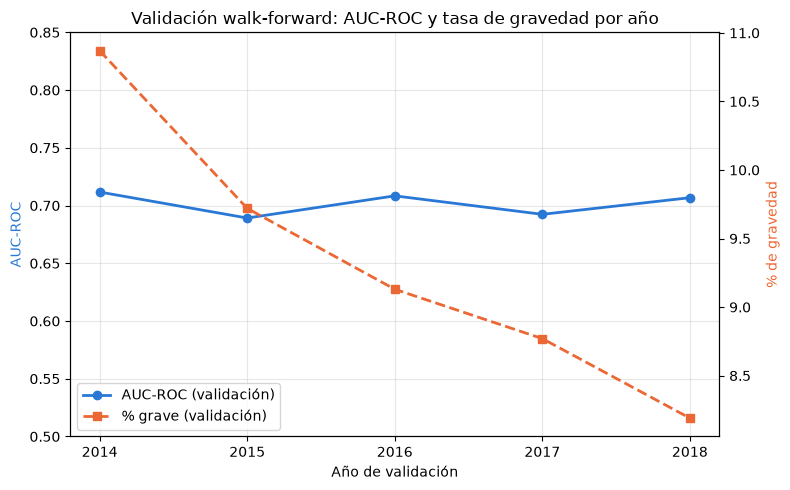

In [25]:
fig = graficar_validacion_temporal(tabla_walkforward, filename='../figures/14_validacion_walkforward.png')


**Conclusión:** el AUC-ROC de validación se mantiene estable entre 0.69 y 0.71 en los 5 años probados, y el valor de 2018 (el test actual del proyecto) queda dentro de ese rango, no en un extremo. Esto respalda que el split temporal elegido (train 2012-2017, test 2018) es representativo del comportamiento general del modelo, y que el descenso observado en la calibración (Sección 1.6) se debe específicamente a la deriva de la tasa base, no a una pérdida de capacidad discriminativa del modelo con el tiempo.


## 2. Modelo explicativo (Pregunta 2)

Se entrena sobre `X_train_ref`/`X_test_ref` — todas las variables, incluido el perfil de las personas implicadas. El objetivo aquí no es solo la métrica de clasificación, sino tener el modelo base para el análisis SHAP de `05_Interpretabilidad.ipynb`. Se usan los mismos candidatos que en la Sección 1, para mantener el criterio de comparación.


In [26]:
modelos_referencia = entrenar_modelos_baseline(X_train_ref, y_train, random_state=RANDOM_STATE)

tabla_referencia = tabla_comparativa_modelos(modelos_referencia, X_train_ref, y_train, X_test_ref, y_test)
tabla_referencia[['AUC-ROC_train', 'AUC-ROC_test', 'gap_AUC-ROC', 'AUC-PR_test', 'Brier score_test']]


,AUC-ROC_train,AUC-ROC_test,gap_AUC-ROC,AUC-PR_test,Brier score_test
Regresión logística,0.7195,0.7116,0.0079,0.1636,0.2185
Random Forest,1.0000,0.6931,0.3069,0.1551,0.0924
Gradient Boosting (Hist),0.7708,0.7242,0.0466,0.1839,0.2075
XGBoost,0.8748,0.6837,0.1911,0.1613,0.1842


In [27]:
import joblib, os

mejor_modelo_ref_nombre = tabla_referencia['AUC-ROC_test'].idxmax()
mejor_modelo_ref = modelos_referencia[mejor_modelo_ref_nombre]
print(f'Mejor modelo de referencia: {mejor_modelo_ref_nombre}')

os.makedirs('../models', exist_ok=True)
joblib.dump(mejor_modelo_ref, '../models/modelo_referencia.joblib')
joblib.dump(modelos_operativo[tabla_operativo['AUC-ROC_test'].idxmax()], '../models/modelo_operativo.joblib')
print('Modelos guardados en ../models/')


Mejor modelo de referencia: Gradient Boosting (Hist)
Modelos guardados en ../models/


## 3. Comparación operativo vs. referencia: ¿cuánto se pierde por restringirse a variables operativas?


In [28]:
mejor_op = tabla_operativo.loc[tabla_operativo['AUC-ROC_test'].idxmax()]
mejor_ref = tabla_referencia.loc[mejor_modelo_ref_nombre]

comparacion = pd.DataFrame({
    'Operativo (Pregunta 1)': mejor_op[['AUC-ROC_test', 'AUC-PR_test', 'Brier score_test']],
    'Referencia (Pregunta 2)': mejor_ref[['AUC-ROC_test', 'AUC-PR_test', 'Brier score_test']],
})
comparacion['Diferencia'] = comparacion['Referencia (Pregunta 2)'] - comparacion['Operativo (Pregunta 1)']
comparacion


,Operativo (Pregunta 1),Referencia (Pregunta 2),Diferencia
AUC-ROC_test,0.7096,0.7242,0.0146
AUC-PR_test,0.1721,0.1839,0.0118
Brier score_test,0.2167,0.2075,-0.0092


**Conclusión:** el modelo de referencia mejora el AUC-ROC de test en torno a 1-2 puntos frente al operativo. Es una ganancia real pero modesta — indica que las variables disponibles en el momento del aviso (Pregunta 1) ya capturan la mayor parte de la señal predictiva; el perfil de las personas implicadas aporta valor incremental, pero no es el factor dominante. Esto refuerza que un sistema de triaje basado solo en información del aviso es razonable, y que el valor añadido de las variables de persona está más en la **interpretación** (Pregunta 2, prevención) que en la mejora bruta de la predicción — que es precisamente lo que se explora en `05_Interpretabilidad.ipynb`.
